In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
IMAGE_DIR = "../data/raw/CADB/images"

image_name = "120.jpg"

image_path = os.path.join(
    IMAGE_DIR,
    image_name
)

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

h, w = gray.shape

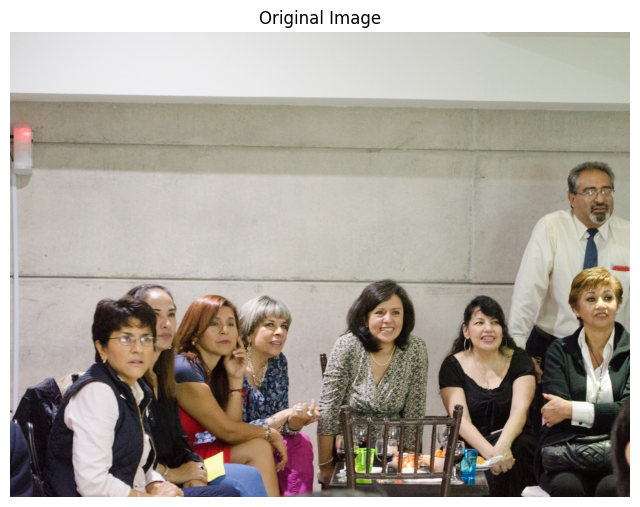

In [4]:
plt.figure(figsize=(8,8))

plt.imshow(img_rgb)

plt.title("Original Image")

plt.axis("off")

plt.show()

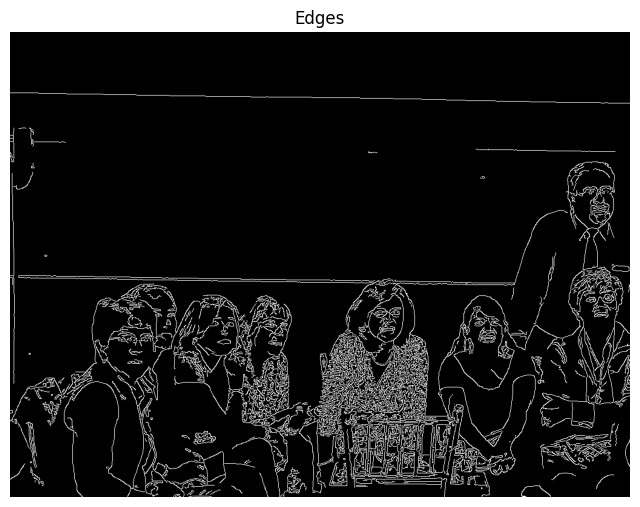

In [5]:
edges = cv2.Canny(
    gray,
    100,
    200
)
plt.figure(figsize=(8,8))

plt.imshow(edges, cmap="gray")

plt.title("Edges")

plt.axis("off")

plt.show()

In [6]:
lines = cv2.HoughLinesP(

    edges,

    1,

    np.pi/180,

    threshold=100,

    minLineLength=100,

    maxLineGap=10
)

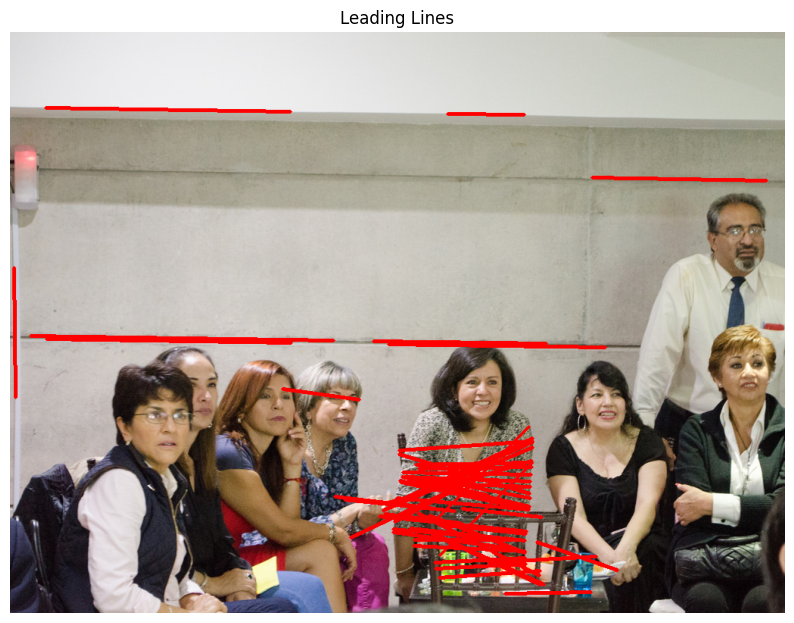

In [7]:
line_img = img_rgb.copy()
if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        cv2.line(

            line_img,

            (x1,y1),

            (x2,y2),

            (255,0,0),

            3
        )
plt.figure(figsize=(10,10))

plt.imshow(line_img)

plt.title("Leading Lines")

plt.axis("off")

plt.show()

In [8]:
angles = []

In [9]:
if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        angle = np.degrees(

            np.arctan2(

                y2 - y1,

                x2 - x1
            )
        )

        angles.append(angle)

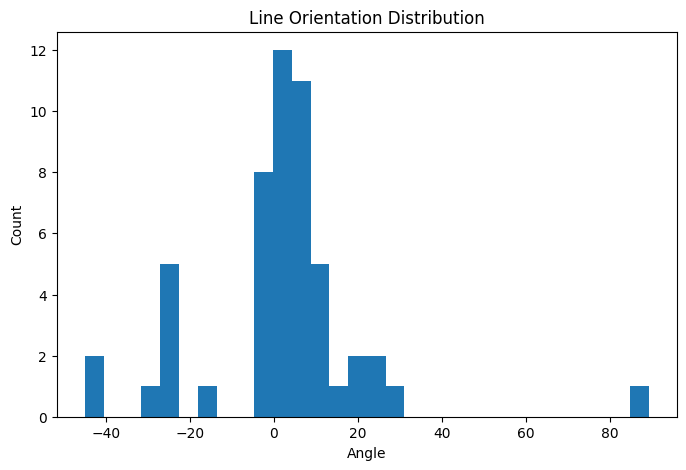

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    angles,
    bins=30
)

plt.title("Line Orientation Distribution")

plt.xlabel("Angle")

plt.ylabel("Count")

plt.show()

In [11]:
flipped = cv2.flip(gray, 1)

In [12]:
symmetry_diff = cv2.absdiff(
    gray,
    flipped
)

In [13]:
symmetry_score = (
    1 - np.mean(symmetry_diff) / 255
)

print("Symmetry Score:", symmetry_score)

Symmetry Score: 0.8244985941967933


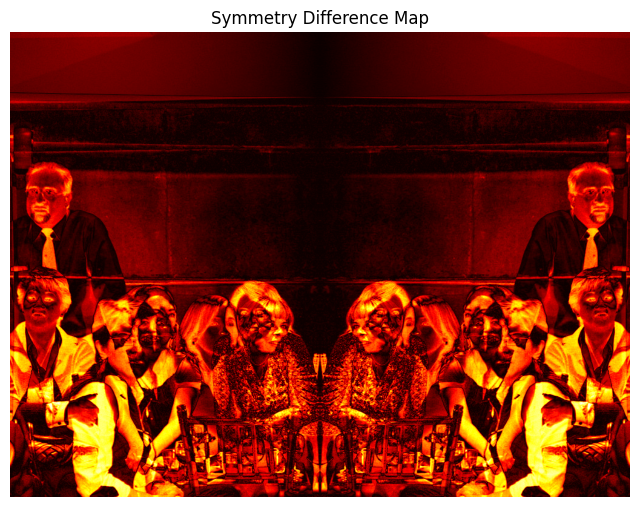

In [14]:
plt.figure(figsize=(8,8))

plt.imshow(
    symmetry_diff,
    cmap="hot"
)

plt.title("Symmetry Difference Map")

plt.axis("off")

plt.show()

In [15]:
horizontal_lines = []

In [16]:
if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        angle = np.degrees(

            np.arctan2(

                y2 - y1,

                x2 - x1
            )
        )

        if abs(angle) < 10:

            horizontal_lines.append(
                (x1,y1,x2,y2)
            )

In [17]:
horizon_img = img_rgb.copy()

In [18]:
for x1, y1, x2, y2 in horizontal_lines:

    cv2.line(

        horizon_img,

        (x1,y1),

        (x2,y2),

        (0,255,0),

        3
    )

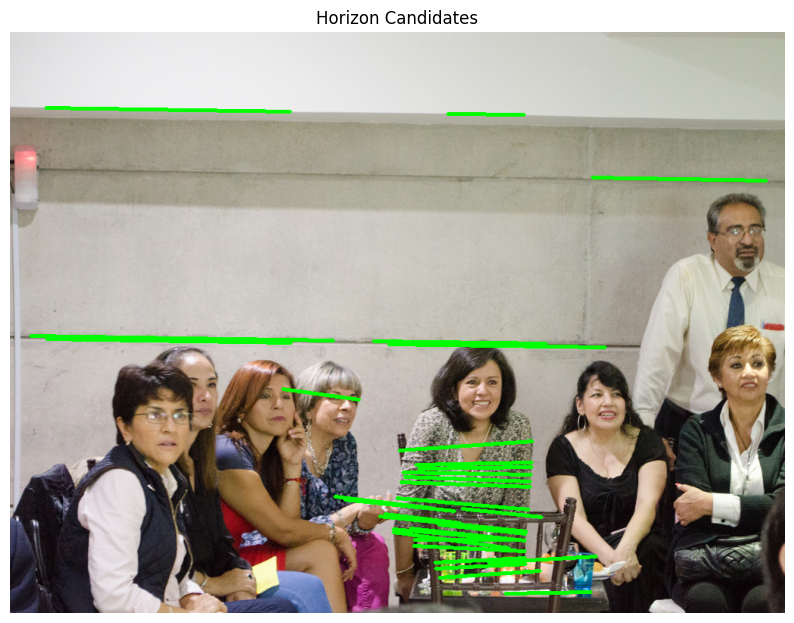

In [19]:
plt.figure(figsize=(10,10))

plt.imshow(horizon_img)

plt.title("Horizon Candidates")

plt.axis("off")

plt.show()

In [20]:
vp_img = img_rgb.copy()

In [21]:
if lines is not None:

    for line in lines[:50]:

        x1, y1, x2, y2 = line[0]

        cv2.line(

            vp_img,

            (x1,y1),

            (x2,y2),

            (255,255,0),

            1
        )

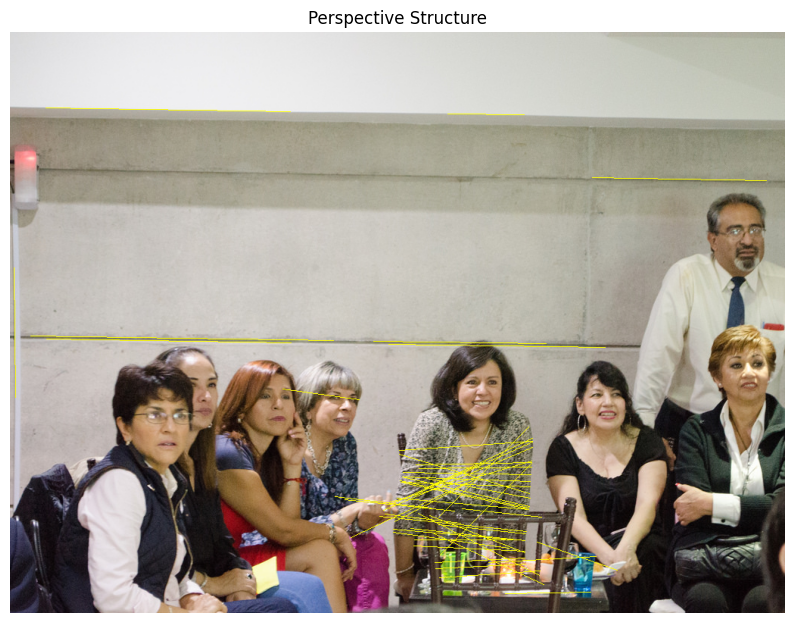

In [22]:
plt.figure(figsize=(10,10))

plt.imshow(vp_img)

plt.title("Perspective Structure")

plt.axis("off")

plt.show()

In [23]:
depth_map = cv2.GaussianBlur(
    gray,
    (21,21),
    0
)

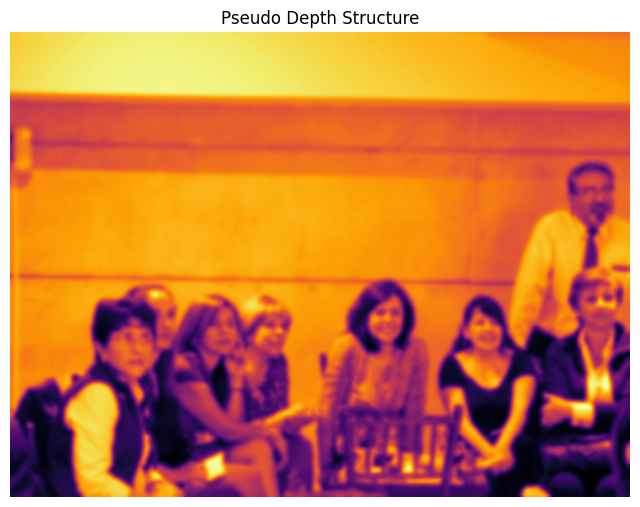

In [24]:
plt.figure(figsize=(8,8))

plt.imshow(
    depth_map,
    cmap="inferno"
)

plt.title("Pseudo Depth Structure")

plt.axis("off")

plt.show()

In [25]:
cinematic_features = {

    "symmetry_score": symmetry_score,

    "num_lines": 0 if lines is None else len(lines),

    "num_horizontal_lines":
        len(horizontal_lines),

    "mean_line_angle":
        np.mean(angles) if len(angles)>0 else 0

}

cinematic_features

{'symmetry_score': np.float64(0.8244985941967933),
 'num_lines': 52,
 'num_horizontal_lines': 31,
 'mean_line_angle': np.float64(1.7695569513801699)}

In [26]:
import pandas as pd

feature_df = pd.DataFrame(
    [cinematic_features]
)

feature_df.to_csv(

    "../data/metadata/cinematic_features.csv",

    index=False
)